In [57]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [58]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.cluster import KMeans

In [59]:
image_path = "../output_videos/cropped_image.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

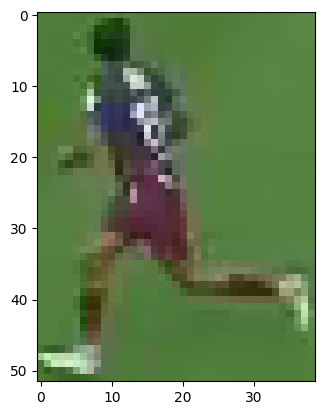

In [60]:
plt.imshow(image)
plt.show()

# taking the top half of the image

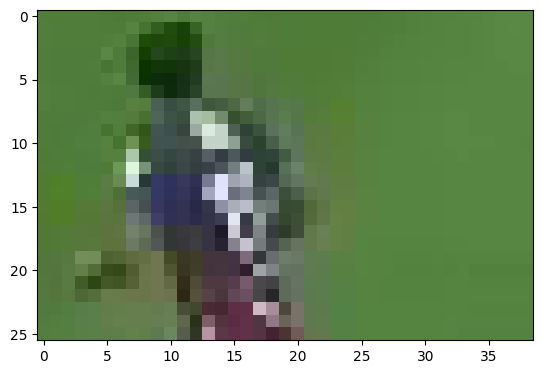

In [61]:
top_half_image = image[0: int(image.shape[0]//2), :]
plt.imshow(top_half_image)
plt.show()

# cluster the image into two clusters

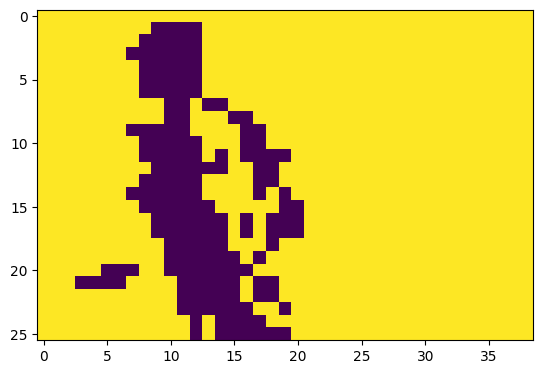

In [62]:
#reshape the image into a 2D array 
image_2d = top_half_image.reshape(-1, 3)

#perform k-means clustering to find the dominant colors
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

#get the cluster labels
labels = kmeans.labels_

#reshape the labels back to the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

#display the clustered image
plt.imshow(clustered_image)
plt.show()


In [63]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [64]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

0


In [65]:
kmeans.cluster_centers_[player_cluster]

array([56.03468208, 64.30057803, 55.04624277])